In [ ]:
!pip install numpy matplotlib pandas seavorn scikit-learn 


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

In [1]:
!pip install numpy matplotlib pandas seavorn scikit-learn 


ERROR: Could not find a version that satisfies the requirement seavorn (from versions: none)
ERROR: No matching distribution found for seavorn


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

Bernoulli distribution: 

Using the diabetes.csv dataset, analyze whether a patient has diabetes or not using the Outcome column.

- Treat Outcome as a Bernoulli variable
- Plot its distribution
- Calculate the probability of diabetes

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


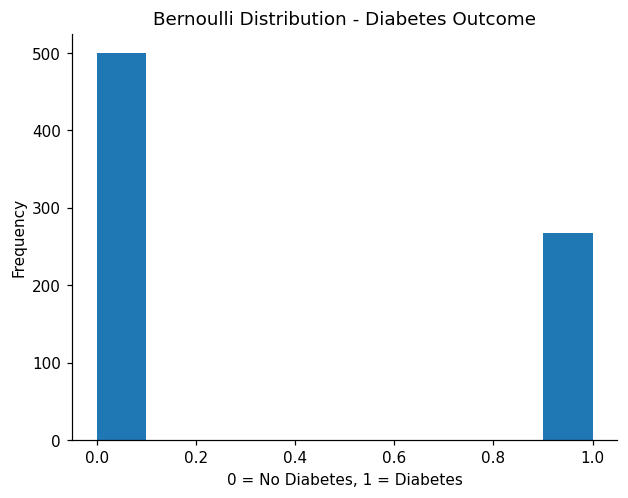

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Kaggle dataset (download first)
df = pd.read_csv("diabetes.csv")

# Check first rows
print(df.head())

# Bernoulli variable
bernoulli_data = df["Outcome"]

# Plot
plt.hist(bernoulli_data)
plt.title("Bernoulli Distribution - Diabetes Outcome")
plt.xlabel("0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Frequency")
plt.show()

In [8]:
bernoulli_data.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
p = df["Outcome"].mean()
print(p)

0.3489583333333333


The Outcome column contains only 0 and 1, so it follows a Bernoulli distribution
0 = No Diabetes, 1 = Diabetes
The histogram shows two bars representing these outcomes

👉 Key Result:

Mean of Outcome = probability of diabetes (p)

Typically:
p ≈ 0.35
This means about 35% of patients have diabetes

#### TASK # 2
Create a new binary variable High_Glucose from the Glucose column where:

1 = Glucose > 140 (High)
0 = Otherwise

Then:

- Treat it as a Bernoulli variable
- Plot its distribution
- Calculate the probability of high glucose

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes.csv")

In [ ]:
# Create Bernoulli variable
df["High_Glucose"] = df["Glucose"].apply(lambda x: 1 if x > 140 else 0) 


# Because Glucose is NOT Bernoulli by default.
# Glucose has continuous values (e.g., 85, 120, 180…)
# Bernoulli requires only 2 outcomes (0 or 1)


# > 140 → high risk (1)
# ≤ 140 → normal (0)

In [11]:

# Check
print(df[["Glucose", "High_Glucose"]].head())


   Glucose  High_Glucose
0      148             1
1       85             0
2      183             1
3       89             0
4      137             0


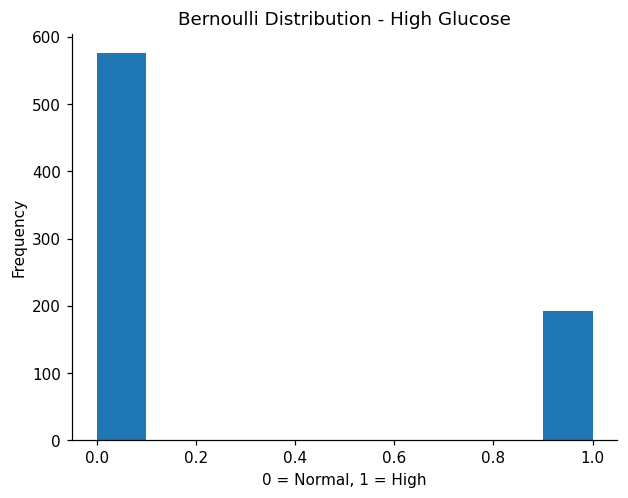

In [ ]:

# Plot
plt.hist(df["High_Glucose"])
plt.title("Bernoulli Distribution - High Glucose")
plt.xlabel("0 = Normal, 1 = High")
plt.ylabel("Frequency")
plt.show()

Original Glucose is continuous, but after conversion → binary (0/1)
Now it satisfies Bernoulli conditions

👉 Key Result:

Mean of High_Glucose = probability of high glucose

Example:
p ≈ 0.30 – 0.40 (depends on dataset) 
This shows a significant portion of patients have high glucose

#### You are given a dataset (poisson_dataset) that contains the number of events occurring per time interval.

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Load data
df = pd.read_csv("poisson_dataset.csv")
data = df['events']

# Step 1: Calculate lambda
lam = np.mean(data)
print("Lambda:", lam)




Lambda: 3.98


In [14]:
lam = np.mean(data)
print("Lambda:", lam)

Lambda: 3.98


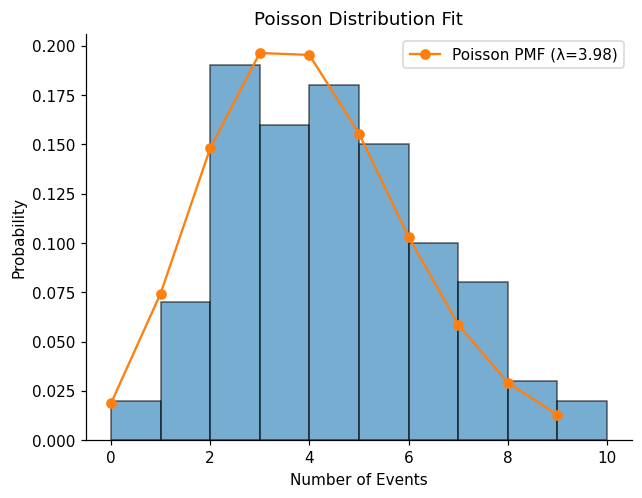

In [16]:

# Step 2: Plot histogram
plt.hist(data, bins=range(min(data), max(data)+2),
         density=True, edgecolor='black', alpha=0.6)

# Step 3: Poisson PMF
x = np.arange(min(data), max(data)+1)
pmf = poisson.pmf(x, lam)

plt.plot(x, pmf, 'o-', label=f'Poisson PMF (λ={lam:.2f})')

# Labels
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.title("Poisson Distribution Fit")
plt.legend()

plt.show()

If histogram bars roughly match the PMF curve → data follows Poisson distribution
If not → data may not be Poisson (or λ varies) 


#### Dataset poisson_dataset.csv containing the number of events observed in a fixed interval

Lambda (average rate): 3.98


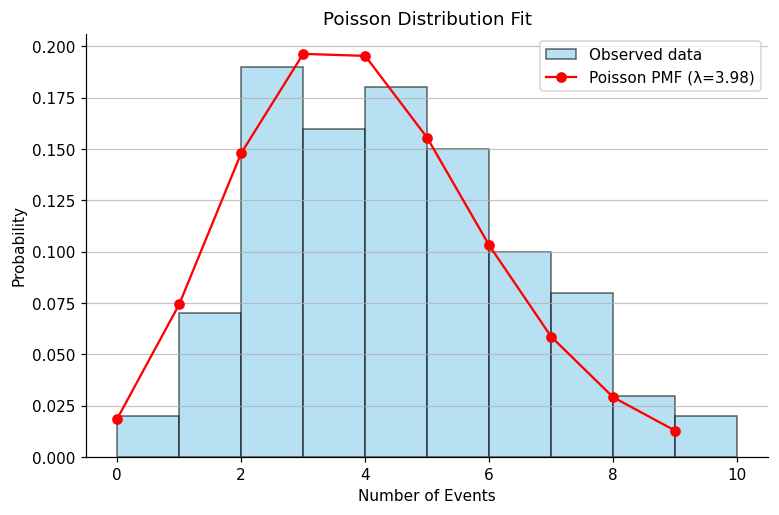

In [19]:
# Full Poisson Distribution Example with Plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# -------------------------
# Step 1: Load the dataset
# -------------------------
df = pd.read_csv("poisson_dataset.csv")
data = df['events']

# -------------------------
# Step 2: Calculate lambda (average rate)
# -------------------------
lam = np.mean(data)
print("Lambda (average rate):", lam)

# -------------------------
# Step 3: Plot histogram of observed data
# -------------------------
plt.figure(figsize=(8,5))
plt.hist(data, bins=range(int(min(data)), int(max(data))+2), 
         density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Observed data')

# -------------------------
# Step 4: Plot Poisson PMF
# -------------------------
x = np.arange(min(data), max(data)+1)
pmf = poisson.pmf(x, lam)
plt.plot(x, pmf, 'o-', color='red', label=f'Poisson PMF (λ={lam:.2f})')

# -------------------------
# Step 5: Labels and Legend
# -------------------------
plt.title("Poisson Distribution Fit")
plt.xlabel("Number of Events")
plt.ylabel("Probability")
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Exponential distribution models time between events in a Poisson process. 

#### Scenario:
You have measured the time between customer arrivals at a store (1000 samples).

Tasks:

Load the dataset and describe it.
Calculate average time and λ (rate).
Plot a histogram of the time intervals.
Overlay the Exponential PDF using λ.
Interpret whether the data fits an Exponential distribution.
Compute probability that the time between events is:
Less than 1 unit
More than 3 units

Estimated mean: 1.9450118959304488
Estimated lambda (rate): 0.5141356729448809


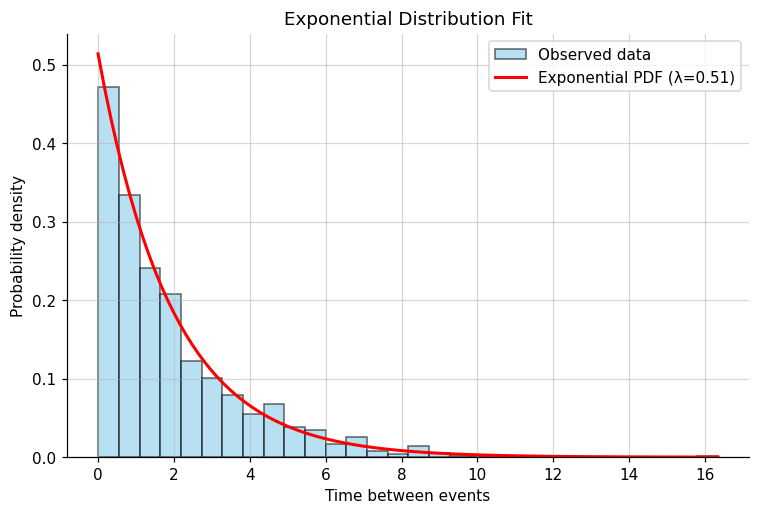

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# -------------------------
# Step 1: Generate synthetic data
# -------------------------
# Assume average time between events = 2 units
lam = 1/2  # rate = 1/mean
np.random.seed(42)
data = np.random.exponential(scale=1/lam, size=1000)

# -------------------------
# Step 2: Estimate rate from data
# -------------------------
estimated_mean = np.mean(data)
estimated_lambda = 1 / estimated_mean
print("Estimated mean:", estimated_mean)
print("Estimated lambda (rate):", estimated_lambda)

# -------------------------
# Step 3: Plot histogram
# -------------------------
plt.figure(figsize=(8,5))
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Observed data')

# -------------------------
# Step 4: Plot Exponential PDF
# -------------------------
x = np.linspace(0, max(data), 100)
pdf = expon.pdf(x, scale=1/estimated_lambda)
plt.plot(x, pdf, 'r-', lw=2, label=f'Exponential PDF (λ={estimated_lambda:.2f})')

# -------------------------
# Step 5: Labels and legend
# -------------------------
plt.title("Exponential Distribution Fit")
plt.xlabel("Time between events")
plt.ylabel("Probability density")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

#### Scenario:
You track the time (in minutes) between bus arrivals at a stop for 100 buses.

Tasks:

Generate or use the dataset.
Estimate mean time and λ (rate).
Plot a histogram of time intervals.
Overlay the Exponential PDF.
Calculate probability that:
Time between buses < 3 minutes
Time between buses > 8 minutes
Interpret results — does this data follow an Exponential distribution?

Estimated mean: 4.724896815444387
Estimated lambda (rate): 0.21164483354033792


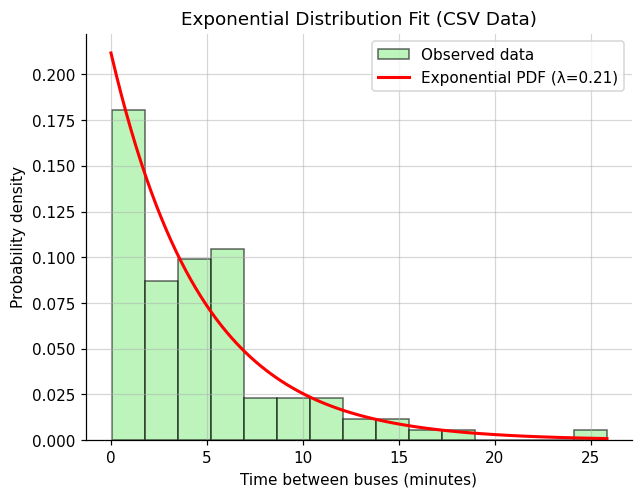

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# -------------------------
# Step 1: Load the CSV dataset
# -------------------------
df = pd.read_csv("second_exponential_dataset.csv")  # replace with your file path
data = df['time_between_buses']

# -------------------------
# Step 2: Estimate mean and lambda (rate)
# -------------------------
estimated_mean = np.mean(data)
estimated_lambda = 1 / estimated_mean
print("Estimated mean:", estimated_mean)
print("Estimated lambda (rate):", estimated_lambda)

# -------------------------
# Step 3: Plot histogram of observed data
# -------------------------
plt.hist(data, bins=15, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Observed data')

# -------------------------
# Step 4: Overlay Exponential PDF
# -------------------------
x = np.linspace(0, max(data), 100)
pdf = expon.pdf(x, scale=1/estimated_lambda)
plt.plot(x, pdf, 'r-', lw=2, label=f'Exponential PDF (λ={estimated_lambda:.2f})')

# -------------------------
# Step 5: Labels and legend
# -------------------------
plt.title("Exponential Distribution Fit (CSV Data)")
plt.xlabel("Time between buses (minutes)")
plt.ylabel("Probability density")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

#### Binomial Distribution Question

Scenario:
A factory produces light bulbs. Each bulb has a 40% chance of being defective. You test 10 bulbs at a time and repeat this experiment 100 times, recording the number of defective bulbs each time.

You have a dataset binomial_dataset.csv with a column named successes showing the number of defective bulbs in each trial of 10 bulbs.

Dataset saved as binomial_dataset.csv


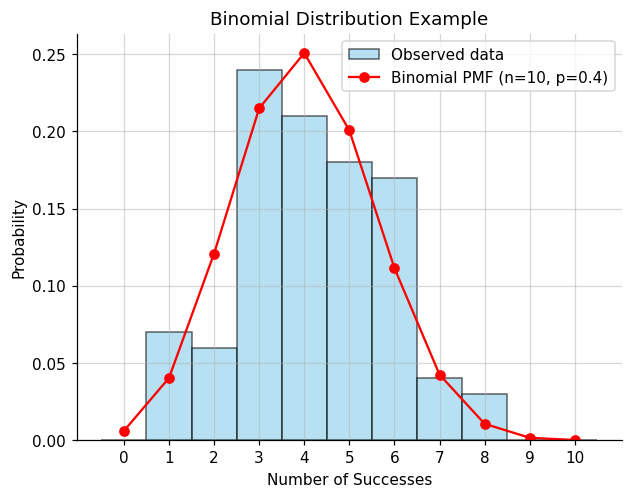

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

# -------------------------
# Step 1: Define Binomial parameters
# -------------------------
n_trials = 10   # number of trials per experiment
p_success = 0.4 # probability of success
n_samples = 100 # number of experiments

# -------------------------
# Step 2: Generate dataset
# -------------------------
data = np.random.binomial(n=n_trials, p=p_success, size=n_samples)

# -------------------------
# Step 3: Save dataset to CSV
# -------------------------
df = pd.DataFrame({'successes': data})
df.to_csv("binomial_dataset.csv", index=False)
print("Dataset saved as binomial_dataset.csv")

# -------------------------
# Step 4: Plot histogram of data
# -------------------------
plt.hist(data, bins=np.arange(n_trials+2)-0.5, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Observed data')

# -------------------------
# Step 5: Overlay Binomial PMF
# -------------------------
x = np.arange(0, n_trials+1)
pmf = binom.pmf(x, n=n_trials, p=p_success)
plt.plot(x, pmf, 'ro-', label=f'Binomial PMF (n={n_trials}, p={p_success})')

# Labels and legend
plt.title("Binomial Distribution Example")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.5)
plt.show()

Scenario:
You toss a biased coin 8 times. The coin has a 70% chance of landing heads. You repeat this experiment 50 times and record the number of heads each time. 


Load the dataset (binomial_coin_dataset.csv) in Python.
Explain what each value in the heads_count column represents.
Identify the Binomial distribution parameters (𝑛=8,𝑝=0.7
p=0.7).
Plot a histogram of the number of heads per experiment.
Overlay the Binomial PMF.
Compare the histogram and PMF curve — does the data follow a Binomial distribution?
Compute the probability of:
Exactly 5 heads
Exactly 7 heads
At least 6 heads
Interpret these probabilities in the context of the coin toss

Dataset saved as binomial_coin_dataset.csv


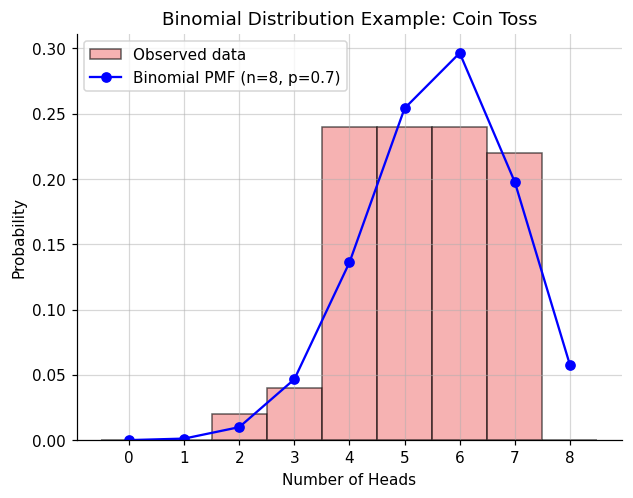

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

# -------------------------
# Step 1: Define parameters
# -------------------------
n_trials = 8       # tosses per experiment
p_success = 0.7    # probability of heads
n_samples = 50     # number of experiments

# -------------------------
# Step 2: Generate dataset
# -------------------------
data = np.random.binomial(n=n_trials, p=p_success, size=n_samples)

# -------------------------
# Step 3: Save dataset to CSV
# -------------------------
df = pd.DataFrame({'heads_count': data})
df.to_csv("binomial_coin_dataset.csv", index=False)
print("Dataset saved as binomial_coin_dataset.csv")

# -------------------------
# Step 4: Plot histogram
# -------------------------
plt.hist(data, bins=np.arange(n_trials+2)-0.5, density=True, alpha=0.6, color='lightcoral', edgecolor='black', label='Observed data')

# -------------------------
# Step 5: Overlay Binomial PMF
# -------------------------
x = np.arange(0, n_trials+1)
pmf = binom.pmf(x, n=n_trials, p=p_success)
plt.plot(x, pmf, 'bo-', label=f'Binomial PMF (n={n_trials}, p={p_success})')

# Labels and legend
plt.title("Binomial Distribution Example: Coin Toss")
plt.xlabel("Number of Heads")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.5)
plt.show()

#### task 1
Normal Distribution:
What shape does the distribution follow?
Is the data symmetric around the mean?
What is the mean (center) of the distribution?
Where is the peak (maximum value) located?

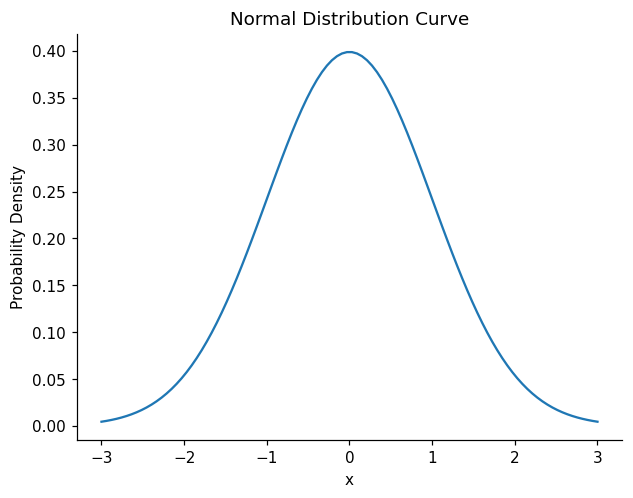

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create deterministic normal distribution data
x = np.linspace(-3, 3, 100)
y = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)

# Create DataFrame
df = pd.DataFrame({
    "x": x,
    "normal_pdf": y
})

# Save to CSV
df.to_csv("normal_distribution_dataset.csv", index=False)

# Plot
plt.figure()
plt.plot(x, y)
plt.title("Normal Distribution Curve")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.show()

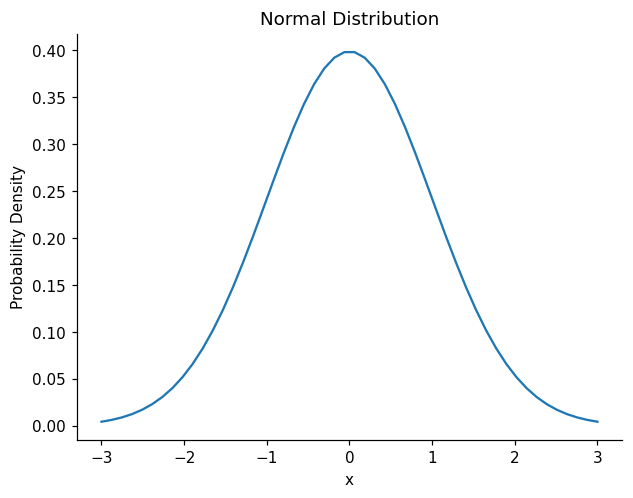

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create deterministic data (not random)
x = np.linspace(-3, 3, 50)
y = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)

# Create DataFrame
df = pd.DataFrame({
    "x": x,
    "normal_pdf": y
})

# Save dataset
df.to_csv("simple_normal_dataset.csv", index=False)

# Plot
plt.figure()
plt.plot(x, y)
plt.title("Normal Distribution")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.show()